<a href="https://colab.research.google.com/github/Bijayaaaa/AI_Internship/blob/Densenet_image_classification/Densenet_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow matplotlib mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 752.6/752.6 kB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 23.6 MB/s eta 0:00:00


In [2]:
from google.colab import files
import zipfile, os

uploaded = files.upload()
zip_path = list(uploaded.keys())[0]

extract_path = "/content/"
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_path)

print("✅ Dataset extracted to:", extract_path)


Saving tiny-imagenet-200.zip to tiny-imagenet-200.zip
✅ Dataset extracted to: /content/


In [3]:
import shutil, pandas as pd

val_dir = "/content/tiny-imagenet-200/val"
val_images_dir = os.path.join(val_dir, "images")
val_annotations = os.path.join(val_dir, "val_annotations.txt")
val_target_dir = os.path.join(val_dir, "processed")

os.makedirs(val_target_dir, exist_ok=True)

df = pd.read_csv(val_annotations, sep='\t', header=None)
df.columns = ["image", "label", "x1", "y1", "x2", "y2"]

for label in df["label"].unique():
    os.makedirs(os.path.join(val_target_dir, label), exist_ok=True)

for _, row in df.iterrows():
    src = os.path.join(val_images_dir, row["image"])
    dst = os.path.join(val_target_dir, row["label"], row["image"])
    if os.path.exists(src):
        shutil.move(src, dst)

print("✅ Validation folder reorganized.")


✅ Validation folder reorganized.


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import mlflow, mlflow.tensorflow, os

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')



In [5]:
mlflow.set_tracking_uri("file:///content/mlruns")  # Local logging
mlflow.set_experiment("Tiny_ImageNet_DenseNet_Light")
mlflow.tensorflow.autolog()


2025/10/29 02:51:03 INFO mlflow.tracking.fluent: Experiment with name 'Tiny_ImageNet_DenseNet_Light' does not exist. Creating a new experiment.


In [6]:
train_dir = "/content/tiny-imagenet-200/train"
val_dir = "/content/tiny-imagenet-200/val/processed"

IMG_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 8
NUM_CLASSES = 200


In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


Found 100000 images belonging to 200 classes.
Found 10000 images belonging to 200 classes.


In [8]:
base = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)
base.trainable = False  # Freeze convolutional backbone

x = GlobalAveragePooling2D()(base.output)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
out = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

model = Model(inputs=base.input, outputs=out)
model.compile(optimizer=Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()



29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 7,351,304 (28.04 MB)

 Trainable params: 313,800 (1.20 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [9]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('densenet_tinyimagenet_light.h5',
                    monitor='val_loss', save_best_only=True)
]



In [10]:
with mlflow.start_run(run_name="DenseNet_Light_Training"):
    history = model.fit(
        train_gen,
        steps_per_epoch=len(train_gen),
        validation_data=val_gen,
        validation_steps=len(val_gen),
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )



2025/10/29 02:51:10 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/10/29 02:51:10 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.1295 - loss: 4.4395

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 506s 76ms/step - accuracy: 0.1295 - loss: 4.4394 - val_accuracy: 0.4621 - val_loss: 2.2739
Epoch 2/8
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4025 - loss: 2.5826

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 474s 74ms/step - accuracy: 0.4025 - loss: 2.5826 - val_accuracy: 0.5063 - val_loss: 2.0517
Epoch 3/8
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4394 - loss: 2.3564

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 465s 74ms/step - accuracy: 0.4394 - loss: 2.3564 - val_accuracy: 0.5243 - val_loss: 1.9456
Epoch 4/8
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4631 - loss: 2.2490

...

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 466s 75ms/step - accuracy: 0.4761 - loss: 2.1773 - val_accuracy: 0.5474 - val_loss: 1.8540
Epoch 6/8
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4895 - loss: 2.1114

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 462s 74ms/step - accuracy: 0.4895 - loss: 2.1114 - val_accuracy: 0.5547 - val_loss: 1.8206
Epoch 7/8
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4948 - loss: 2.0906

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 464s 74ms/step - accuracy: 0.4948 - loss: 2.0906 - val_accuracy: 0.5576 - val_loss: 1.8128
Epoch 8/8
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4979 - loss: 2.0739

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 463s 74ms/step - accuracy: 0.4979 - loss: 2.0739 - val_accuracy: 0.5584 - val_loss: 1.7972


2025/10/29 03:53:55 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: '>=' not supported between instances of 'slice' and 'int'
2025/10/29 03:53:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/29 03:53:55 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/10/29 03:54:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


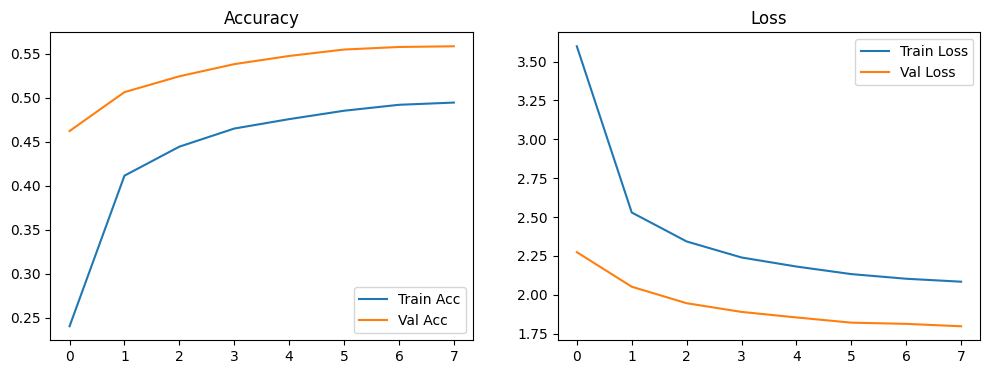

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss')

plt.show()



1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
🖼️ Predicted Class: n04560804


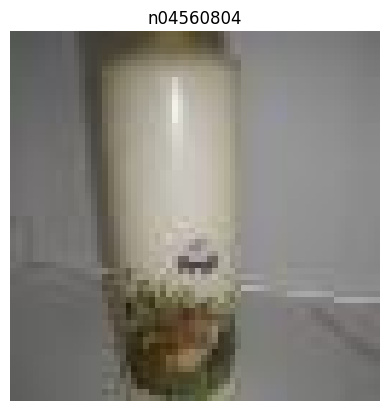

In [12]:
from tensorflow.keras.preprocessing import image
import numpy as np

model = tf.keras.models.load_model('densenet_tinyimagenet_light.h5')
class_names = sorted(os.listdir(train_dir))

img_path = "/content/tiny-imagenet-200/test/images/test_0.JPEG"  # Upload any test image
img = image.load_img(img_path, target_size=IMG_SIZE)
img_arr = image.img_to_array(img)/255.0
img_arr = np.expand_dims(img_arr, axis=0)

preds = model.predict(img_arr)
pred_class = class_names[np.argmax(preds)]
print("🖼️ Predicted Class:", pred_class)

plt.imshow(image.load_img(img_path))
plt.title(pred_class)
plt.axis('off')
plt.show()
